## Questão 3 - Custos de Importação

**Cenário**

Além dos dados de produtos, Gabriel percebeu também que o arquivo custos_importacao.json tem todos os dados históricos dos preços de compra aninhados num único campo. Para facilitar a análise dessa informação no banco de dados é necessário melhorarmos isso.



**Premissas obrigatórias**  
Utilize apenas o JSON custos_importacao.json   
Utilize obrigatoriamente Python 3   

**Tarefa:**  
- Carregue o arquivo JSON e gere um novo arquivo CSV organizando-o de acordo com a definição na imagem abaixo.
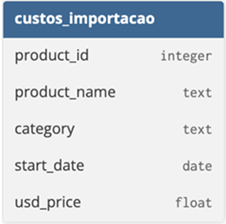

In [2]:
import pandas as pd
import json

# Convertendo o arquivo JSON "custos_importacao" para dataframe

rows = []

with open(r'raw_data\JSON\custos_importacao.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

for product in data:
    for hist in product['historic_data']:
        rows.append({
            'product_id': product['product_id'],
            'product_name': product['product_name'],
            'category': product['category'],
            'start_date': hist['start_date'],
            'usd_price': hist['usd_price']
        })

df_costs = pd.DataFrame(rows)

In [3]:
# Checando tipos das colunas

df_costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    1260 non-null   int64  
 1   product_name  1260 non-null   object 
 2   category      1260 non-null   object 
 3   start_date    1260 non-null   object 
 4   usd_price     1260 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 49.3+ KB


=> Coluna de datas precisa ser convertida

In [4]:
df_costs['start_date'].head(10)

0    10/08/2016
1    15/06/2018
2    25/09/2018
3    19/03/2019
4    17/01/2020
5    17/06/2020
6    02/07/2021
7    16/05/2022
8    28/02/2023
9    17/10/2023
Name: start_date, dtype: object

=> Datas no formato DD/MM/YYYY não foram convertidas automaticamente

In [5]:
# Convertendo a coluna de datas

df_costs['start_date'] = pd.to_datetime(df_costs['start_date'], dayfirst=True)

In [6]:
# Checando a nova coluna

print(df_costs['start_date'].dtype) 
print(df_costs['start_date'].head())

datetime64[ns]
0   2016-08-10
1   2018-06-15
2   2018-09-25
3   2019-03-19
4   2020-01-17
Name: start_date, dtype: datetime64[ns]


In [73]:
# Exportando para arquivo CSV

df_costs.to_csv('custos_importacao.csv', index=False)